In [7]:
import pandas as pd
import numpy as np
import scipy.stats
import sklearn
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
lab_master = pd.read_csv('/content/clean_lab_master_v3 (1).csv')

In [9]:
print(f"DataFrame shape: {lab_master.shape}")
print(f"DataFrame columns: {lab_master.columns.tolist()}")

DataFrame shape: (76069, 18)
DataFrame columns: ['row_id', 'subject_id', 'hadm_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom', 'flag', 'is_abnormal', 'label', 'category', 'fluid', 'loinc_code', 'los_days', 'admission_type', 'gender', 'dob']


### T-test: Mean `valuenum` between MALE and FEMALE gender groups

In [10]:
male_valuenum = lab_master[lab_master['gender'] == 'M']['valuenum'].dropna()
female_valuenum = lab_master[lab_master['gender'] == 'F']['valuenum'].dropna()

t_stat_gender, p_val_gender = scipy.stats.ttest_ind(male_valuenum, female_valuenum)

print(f"T-statistic (valuenum by gender): {t_stat_gender:.4f}")
print(f"P-value (valuenum by gender): {p_val_gender:.4f}")

if p_val_gender < 0.05:
    print("Conclusion: The difference in mean valuenum between MALE and FEMALE gender groups is statistically significant (p < 0.05).")
else:
    print("Conclusion: The difference in mean valuenum between MALE and FEMALE gender groups is not statistically significant (p >= 0.05).")

T-statistic (valuenum by gender): -0.1436
P-value (valuenum by gender): 0.8858
Conclusion: The difference in mean valuenum between MALE and FEMALE gender groups is not statistically significant (p >= 0.05).


### Chi-square test: `is_abnormal` and `gender`

In [11]:
contingency_table = pd.crosstab(lab_master['is_abnormal'], lab_master['gender'])
chi2_stat_abnormal_gender, p_val_abnormal_gender, _, _ = scipy.stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic (is_abnormal vs gender): {chi2_stat_abnormal_gender:.4f}")
print(f"P-value (is_abnormal vs gender): {p_val_abnormal_gender:.4f}")

if p_val_abnormal_gender < 0.05:
    print("Conclusion: 'is_abnormal' and 'gender' are statistically related (p < 0.05).")
else:
    print("Conclusion: 'is_abnormal' and 'gender' are not statistically related (p >= 0.05).")

Chi-square statistic (is_abnormal vs gender): 24.8379
P-value (is_abnormal vs gender): 0.0000
Conclusion: 'is_abnormal' and 'gender' are statistically related (p < 0.05).


### T-test: `los_days` between EMERGENCY and ELECTIVE admission types

In [12]:
emergency_los = lab_master[lab_master['admission_type'] == 'EMERGENCY']['los_days'].dropna()
elective_los = lab_master[lab_master['admission_type'] == 'ELECTIVE']['los_days'].dropna()

t_stat_los, p_val_los = scipy.stats.ttest_ind(emergency_los, elective_los)

print(f"T-statistic (los_days by admission type): {t_stat_los:.4f}")
print(f"P-value (los_days by admission type): {p_val_los:.4f}")

if p_val_los < 0.05:
    print("Conclusion: The difference in mean los_days between EMERGENCY and ELECTIVE admission types is statistically significant (p < 0.05).")
else:
    print("Conclusion: The difference in mean los_days between EMERGENCY and ELECTIVE admission types is not statistically significant (p >= 0.05).")

T-statistic (los_days by admission type): 11.4728
P-value (los_days by admission type): 0.0000
Conclusion: The difference in mean los_days between EMERGENCY and ELECTIVE admission types is statistically significant (p < 0.05).


### Data Preparation, Scaling, Clustering, and Visualization

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select columns and drop rows where valuenum or los_days is 0 or null
clustering_data = lab_master[['valuenum', 'los_days']].copy()
clustering_data = clustering_data[(clustering_data['valuenum'] != 0) & (clustering_data['los_days'] != 0)].dropna()

print(f"Shape of data after filtering: {clustering_data.shape}")

Shape of data after filtering: (59078, 2)


In [14]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data[['valuenum', 'los_days']])
scaled_df = pd.DataFrame(scaled_data, columns=['valuenum_scaled', 'los_days_scaled'], index=clustering_data.index)

print("Scaled data head:")
display(scaled_df.head())

Scaled data head:


,valuenum_scaled,los_days_scaled
633,-0.113948,-0.56539
634,-0.105190,-0.56539
635,-0.115852,-0.56539
636,0.195635,-0.56539
637,-0.084247,-0.56539


In [15]:
# Apply KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init=10 to suppress warning
clustering_data['cluster'] = kmeans.fit_predict(scaled_df)

print("Data with cluster labels head:")
display(clustering_data.head())

Data with cluster labels head:


,valuenum,los_days,cluster
633,4.4,8.0,1
634,9.0,8.0,1
635,3.4,8.0,1
636,167.0,8.0,1
637,20.0,8.0,1


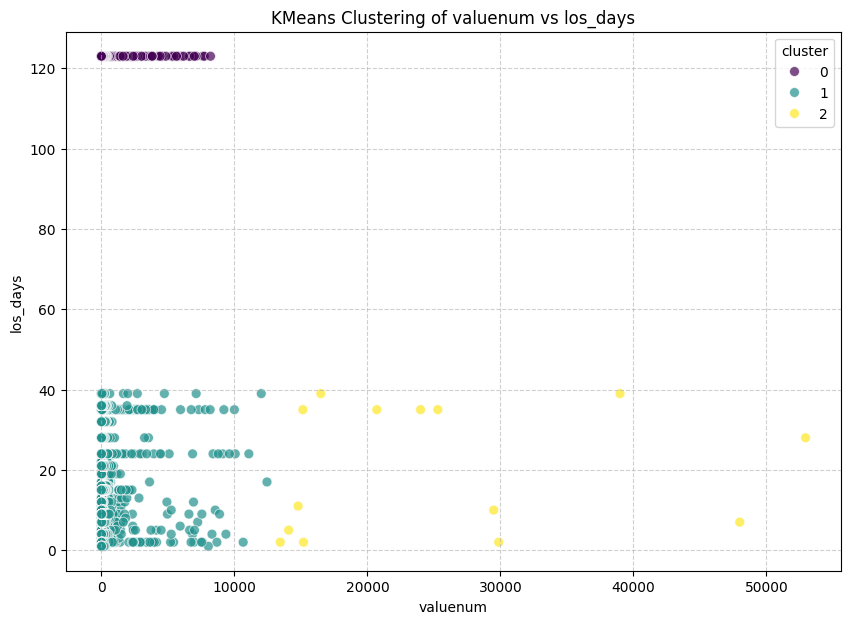

In [16]:
# Plot scatter plot of valuenum vs los_days colored by cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(x='valuenum', y='los_days', hue='cluster', data=clustering_data, palette='viridis', s=50, alpha=0.7)
plt.title('KMeans Clustering of valuenum vs los_days')
plt.xlabel('valuenum')
plt.ylabel('los_days')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [17]:
# Print value counts of each cluster
print("Value counts for each cluster:")
print(clustering_data['cluster'].value_counts())

Value counts for each cluster:
cluster
1    52652
0     6412
2       14
Name: count, dtype: int64


### Time Series Analysis: Monthly Lab Test Trends

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Convert 'charttime' to datetime
lab_master['charttime'] = pd.to_datetime(lab_master['charttime'])

# Group by month and count the number of lab tests
monthly_counts = lab_master.set_index('charttime').resample('M').size().reset_index(name='count')
monthly_counts['month_index'] = np.arange(len(monthly_counts))

print("Monthly counts head:")
display(monthly_counts.head())

Monthly counts head:


/tmp/ipykernel_2883/1474473825.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = lab_master.set_index('charttime').resample('M').size().reset_index(name='count')


,charttime,count,month_index
0,2102-08-31,161,0
1,2102-09-30,98,1
2,2102-10-31,0,2
3,2102-11-30,0,3
4,2102-12-31,0,4


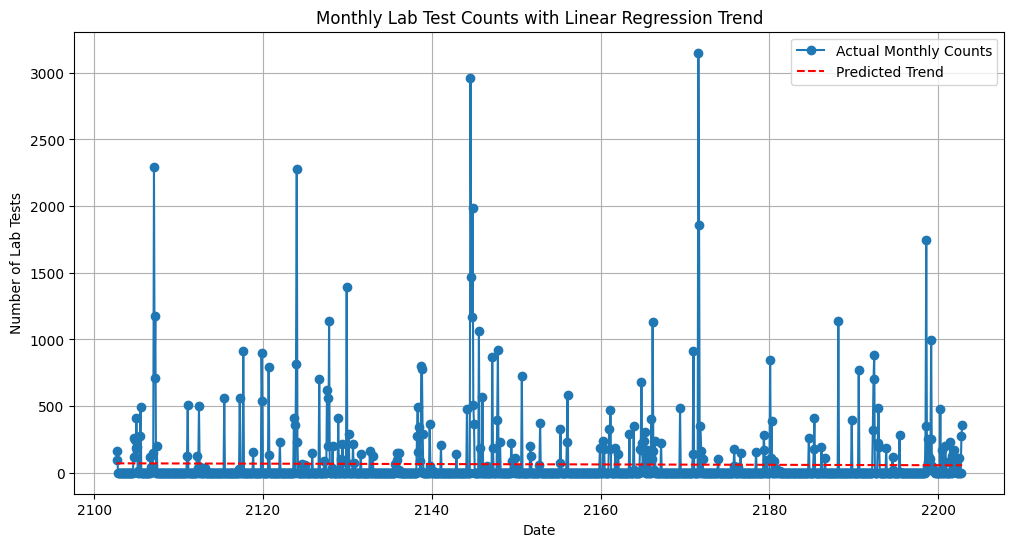

In [19]:
# Prepare data for Linear Regression
X = monthly_counts[['month_index']]
Y = monthly_counts['count']

# Fit a Linear Regression model
model = LinearRegression()
model.fit(X, Y)

# Predict the trend
monthly_counts['predicted_count'] = model.predict(X)

# Plot actual monthly counts and predicted trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts['charttime'], monthly_counts['count'], label='Actual Monthly Counts', marker='o')
plt.plot(monthly_counts['charttime'], monthly_counts['predicted_count'], label='Predicted Trend', linestyle='--', color='red')
plt.title('Monthly Lab Test Counts with Linear Regression Trend')
plt.xlabel('Date')
plt.ylabel('Number of Lab Tests')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Print the R² score and slope
r2 = r2_score(Y, monthly_counts['predicted_count'])
slope = model.coef_[0]

print(f"R² Score: {r2:.4f}")
print(f"Slope of the trend line: {slope:.4f}")

if slope > 0:
    print("Conclusion: There is an increasing trend in monthly lab tests.")
elif slope < 0:
    print("Conclusion: There is a decreasing trend in monthly lab tests.")
else:
    print("Conclusion: There is no significant linear trend in monthly lab tests.")

R² Score: 0.0003
Slope of the trend line: -0.0120
Conclusion: There is a decreasing trend in monthly lab tests.


### Summary Statistics: `valuenum` by Gender

In [21]:
valuenum_gender_stats = lab_master.groupby('gender')['valuenum'].agg(['mean', 'median', 'std'])
print("Mean, Median, and Std Dev of 'valuenum' by Gender:")
display(valuenum_gender_stats)

Mean, Median, and Std Dev of 'valuenum' by Gender:


,mean,median,std
gender,,,
F,67.842434,13.8,619.604104
M,67.220963,12.0,570.131226


### Summary Statistics: `los_days` by Admission Type

In [22]:
los_days_admission_stats = lab_master[lab_master['admission_type'] != 'UNKNOWN'].groupby('admission_type')['los_days'].agg(['mean', 'median', 'std'])
print("Mean, Median, and Std Dev of 'los_days' by Admission Type (excluding UNKNOWN):")
display(los_days_admission_stats)

Mean, Median, and Std Dev of 'los_days' by Admission Type (excluding UNKNOWN):


,mean,median,std
admission_type,,,
ELECTIVE,20.803759,12.0,14.707116
EMERGENCY,28.271206,13.0,36.306210
URGENT,5.544747,6.0,0.498479


### Abnormal Rate by Gender

In [23]:
abnormal_rate_gender = lab_master.groupby('gender')['is_abnormal'].mean() * 100
print("Abnormal Rate (percentage of is_abnormal = True) by Gender:")
display(abnormal_rate_gender.to_frame(name='Abnormal Rate (%)'))

Abnormal Rate (percentage of is_abnormal = True) by Gender:


,Abnormal Rate (%)
gender,
F,37.944814
M,39.709828


### Logistic Regression: Patient-level high abnormal-risk classification


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Build patient-level dataset from event-level lab records
patient_level = (
    lab_master.groupby('subject_id')
    .agg(
        total_tests=('is_abnormal', 'size'),
        abnormal_count=('is_abnormal', 'sum'),
        abnormal_rate=('is_abnormal', 'mean'),
        mean_valuenum=('valuenum', 'mean'),
        std_valuenum=('valuenum', 'std'),
        mean_los_days=('los_days', 'mean'),
        emergency_ratio=('admission_type', lambda s: (s == 'EMERGENCY').mean()),
        male_ratio=('gender', lambda s: (s == 'M').mean())
    )
    .reset_index()
)

# Target: high abnormal-risk patients (>= 75th percentile abnormal_rate)
risk_cutoff = patient_level['abnormal_rate'].quantile(0.75)
patient_level['high_abnormal_risk'] = (patient_level['abnormal_rate'] >= risk_cutoff).astype(int)

# Prepare features (excluding target-defining columns)
feature_cols = ['total_tests', 'mean_valuenum', 'std_valuenum', 'mean_los_days', 'emergency_ratio', 'male_ratio']
X = patient_level[feature_cols].fillna(0)
y = patient_level['high_abnormal_risk']

# Train logistic regression classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

risk_model = LogisticRegression(max_iter=2000, random_state=42)
risk_model.fit(X_train, y_train)

y_pred = risk_model.predict(X_test)
y_prob = risk_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy (patient high-risk classification): {accuracy:.4f}")
print(f"Precision (patient high-risk classification): {precision:.4f}")
print(f"Recall (patient high-risk classification): {recall:.4f}")
print(f"ROC-AUC (patient high-risk classification): {auc:.4f}")

if auc >= 0.70:
    print("Conclusion: The model shows good discrimination for identifying high-risk patients (ROC-AUC >= 0.70).")
elif auc >= 0.60:
    print("Conclusion: The model shows moderate discrimination for identifying high-risk patients (0.60 <= ROC-AUC < 0.70).")
else:
    print("Conclusion: The model shows limited discrimination for identifying high-risk patients (ROC-AUC < 0.60).")

# Score all patients and list the top predicted high-risk cases
patient_level['risk_probability'] = risk_model.predict_proba(X)[:, 1]

high_risk_patients = (
    patient_level[['subject_id', 'risk_probability', 'abnormal_rate', 'total_tests', 'mean_los_days']]
    .sort_values('risk_probability', ascending=False)
    .head(25)
)

print("\nTop 25 high-risk patients by predicted probability:")
display(high_risk_patients)

Accuracy (patient high-risk classification): 0.9000
Precision (patient high-risk classification): 1.0000
Recall (patient high-risk classification): 0.6000
ROC-AUC (patient high-risk classification): 0.8800
Conclusion: The model shows good discrimination for identifying high-risk patients (ROC-AUC >= 0.70).

Top 25 high-risk patients by predicted probability:


,subject_id,risk_probability,abnormal_rate,total_tests,mean_los_days
66,41976,0.991918,0.484316,4495,6.802670
46,10126,0.932996,0.439297,5008,34.706470
42,10117,0.808933,0.429002,2324,1.472892
71,42135,0.757230,0.529738,2522,12.053529
0,10006,0.664478,0.423841,1963,1.022924
92,43881,0.623382,0.329140,1431,2.450734
44,10120,0.556269,0.665474,559,2.000000
81,42412,0.537296,0.432632,950,1.566316
35,10101,0.525916,0.416309,233,1.090129
91,43879,0.524390,0.379209,683,0.000000
